In [1]:
import scipy as sp
from pylab import *
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.pylab as pylab
import pandas as pd
import seaborn as sns
import random
import openpyxl


from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

sns.set_style("ticks")

params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}



session_name="results/test"


In [20]:
def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def input_distribution(k):
    return np.random.exponential(k)

def hiearchy_score_1(DominanceMatrix_BC,competitive_scores, num_C):
    valdist=DominanceMatrix_BC.ravel()[np.flatnonzero(DominanceMatrix_BC)]
    valdist=valdist[~np.isnan(valdist)]
    return (var(competitive_scores[:]))/(np.var(valdist)/(num_C-1))

def InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name):
    
    CommunitiesLibrary=np.zeros([num_C, N])
    for i in range(num_C):
        #CommunitiesLibrary[i,random.sample(list(np.arange(N)), num_S)]=1
        CommunitiesLibrary[i,np.arange(num_S*i,num_S*(i+1))]=1
    df1=pd.DataFrame(CommunitiesLibrary)
    with pd.ExcelWriter(save_path+'/commuityLibrary.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
    return CommunitiesLibrary

def calculate_hierarchy_score(matrix):
    # get lower triangle of sorted matrix
    
    mean_indices = np.argsort(-np.nanmean(matrix, axis=1))
    # get mean of each column and sort indices
    col_mean_indices = np.argsort(np.nanmean(matrix, axis=0))
    
    # create sorted matrix based on sorted row and column indices
    sorted_matrix = matrix[mean_indices][:, col_mean_indices]
                                         
    lower_triangle = np.tril(sorted_matrix, k=-1)
    # get non-NaN values in lower triangle
    mask = np.tril(np.ones_like(sorted_matrix), k=-1).astype(np.bool)
    non_nan_values = sorted_matrix[mask][~np.isnan(sorted_matrix[mask])]
    
    # calculate sum and count of non-NaN values
    sum_non_nan = np.sum(non_nan_values)
    num_non_nan = len(non_nan_values)
    
    # calculate hierarchy score
    hierarchy_score = 1 - sum_non_nan / num_non_nan
    
    return hierarchy_score

def generate_random_matrix(matrix):
    random_fractions = np.random.choice(matrix.flatten(), size=matrix.size, replace=True)
    random_matrix = np.zeros(matrix.shape)
    idx=np.tril_indices(matrix.shape[0],k=-1)

    random_matrix[np.tril_indices(matrix.shape[0],k=-1)] = random_fractions[0:len(idx[0])]
    random_matrix[np.triu_indices(matrix.shape[0],k=1)] = 1-random_fractions[0:len(idx[0])]
    np.fill_diagonal(random_matrix, 0.5)
    
    return random_matrix

def calculate_significance(matrix, n_samples=1000):
    # Calculate hierarchy score for original matrix
    hierarchy_score = calculate_hierarchy_score(matrix)
    
    # Generate random matrices and calculate hierarchy scores
    random_scores = []
    for i in range(n_samples):
        random_matrix = generate_random_matrix(matrix)
        random_scores.append(calculate_hierarchy_score(random_matrix))
    
    # Calculate p-value
    random_scores = np.array(random_scores)
    p_value = (random_scores >= hierarchy_score).sum() / n_samples
    
    return random_scores, p_value


Num=20
u=0.33
o=0.1
num_C=8
num_S=12
N=num_C*num_S
hs_list=np.array([])
for i in range(Num):
    f_interaction=lambda : uniform_distribution(u,o)
    #f_interaction=lambda : input_distribution(0.6)

    I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)


    
    DominanceMatrix_BC=np.zeros([num_C,num_C])
    DominanceMatrix_J=np.zeros([num_C,num_C])
    DominanceMatrix_JS=np.zeros([num_C,num_C])

    threshold=0.0001
    y_list=np.zeros([num_C,N])
    for i in range(num_C):
        y=np.random.rand(N)*0.1
        y=run_lotka_volterra(y, np.linspace(0, 2500, 7500), CommunitiesLibrary[i,:], I, g, k)
        y[y<threshold]=0
        y_list[i,:]=y

    for i in range(num_C):
        for j in range(i,num_C):#range(i,num_C):
            y1= y_list[i,:]
            y2= y_list[j,:]


            y3=run_lotka_volterra((y1+y2)/2, np.linspace(0, 2500, 7500), (y1+y2)>threshold, I, g, k)
            y3[y3<threshold]=0

            DominanceMatrix_BC[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))
            DominanceMatrix_BC[j,i]=1-DominanceMatrix_BC[i,j]
            DominanceMatrix_J[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityJ(x,y,z)))
            DominanceMatrix_J[j,i]=1-DominanceMatrix_J[i,j]
            DominanceMatrix_JS[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityJS(x,y,z)))
            DominanceMatrix_JS[j,i]=1-DominanceMatrix_JS[i,j]

    matrix=DominanceMatrix_J
    df = pd.DataFrame(matrix)
    df_sorted=df.sort_index(axis=1)
    df_sorted=df_sorted.sort_index(axis=0)

    # Create list of competitive scores

    competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

    # Sort rows and columns by competitive score
    sorted_idx = np.argsort(competitive_scores)[::-1]
    df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
    df1=df_sorted

    # Create heatmap with clustered rows and columns
    hs=calculate_hierarchy_score(df.values)
    hs_list=np.append(hs_list,hs)
    #permutated_scores, p_value=calculate_significance(df.values,1000)

    #plt.hist(permutated_scores, bins=50, alpha=0.5,range=(0.5, 1), density=True)
    print(hs)
    # plot dotted line for actual score
    #plt.axvline(x=hs, linestyle='--', color='red', label='Actual Score')
    #plt.text(0.1, 0.9, f'p = {p_value:.4f}', ha='center', va='center', transform=plt.gca().transAxes)

                    # add legend and axis labels
    #plt.legend()
    #plt.xlabel('Hierarchy Scores')
    #plt.ylabel('Frequency')

                    # show plot
    #plt.show()

        


Folder 'results/test' already exists.


/var/folders/jx/rq_jr02135l_jt9wtyd2x47c0000gn/T/ipykernel_96369/1896596265.py:35: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.tril(np.ones_like(sorted_matrix), k=-1).astype(np.bool)


0.5688059674963907
Folder 'results/test' already exists.
0.6023142528443484
Folder 'results/test' already exists.
0.5837917741649561
Folder 'results/test' already exists.
0.5691878846100824
Folder 'results/test' already exists.
0.6117850391108998
Folder 'results/test' already exists.
0.6087441959360633
Folder 'results/test' already exists.
0.6196515756495621
Folder 'results/test' already exists.
0.6158672468365344
Folder 'results/test' already exists.
0.5630617043397905
Folder 'results/test' already exists.
0.5701670893792654
Folder 'results/test' already exists.
0.6070902317496616
Folder 'results/test' already exists.
0.6338874336025939
Folder 'results/test' already exists.
0.675300169696422
Folder 'results/test' already exists.
0.6220537447264405
Folder 'results/test' already exists.
0.551906474981048
Folder 'results/test' already exists.
0.6451985232772572
Folder 'results/test' already exists.
0.5734415096516605
Folder 'results/test' already exists.
0.5949342583055807
Folder 'result

In [22]:
hs1=hs_list

0.572037414018132


/var/folders/jx/rq_jr02135l_jt9wtyd2x47c0000gn/T/ipykernel_96369/1896596265.py:35: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.tril(np.ones_like(sorted_matrix), k=-1).astype(np.bool)


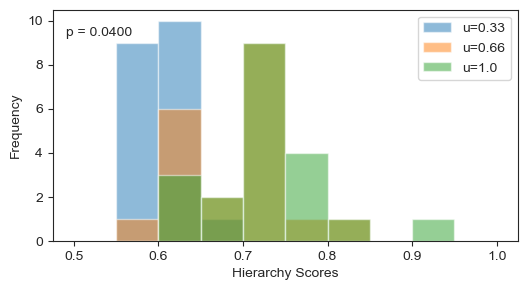

1.2528388869315168

In [24]:

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 3), dpi=100, facecolor='w', edgecolor='k')
                
hs=calculate_hierarchy_score(df.values)

plt.hist(hs1, bins=10, alpha=0.5,range=(0.5, 1), density=True, label="u=0.33")
plt.hist(hs2, bins=10, alpha=0.5,range=(0.5, 1), density=True, label="u=0.66")
plt.hist(hs3, bins=10, alpha=0.5,range=(0.5, 1), density=True, label="u=1.0")
print(hs)
# plot dotted line for actual score
plt.text(0.1, 0.9, f'p = {p_value:.4f}', ha='center', va='center', transform=plt.gca().transAxes)

                # add legend and axis labels
plt.legend()
plt.xlabel('Hierarchy Scores')
plt.ylabel('Frequency')

                # show plot
plt.show()

hiearchy_score_1(DominanceMatrix_BC,competitive_scores, num_C)


<AxesSubplot: xlabel='type', ylabel='data'>

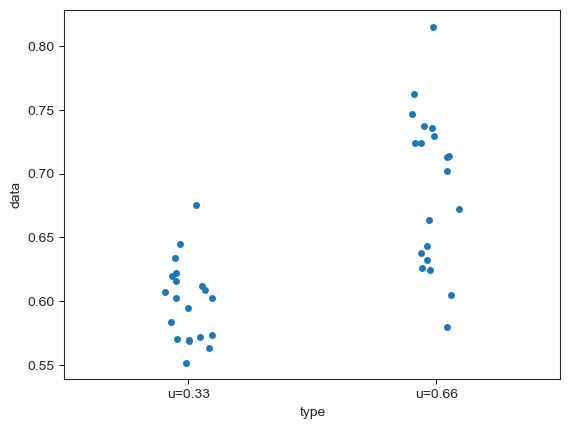

In [36]:
sns.stripplot(x='type',y='data', data=df)

/var/folders/jx/rq_jr02135l_jt9wtyd2x47c0000gn/T/ipykernel_96369/3641762254.py:54: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='type',y='data', data=df, palette=palette, size=5, alpha=0.3)


AttributeError: 'NoneType' object has no attribute 'remove'

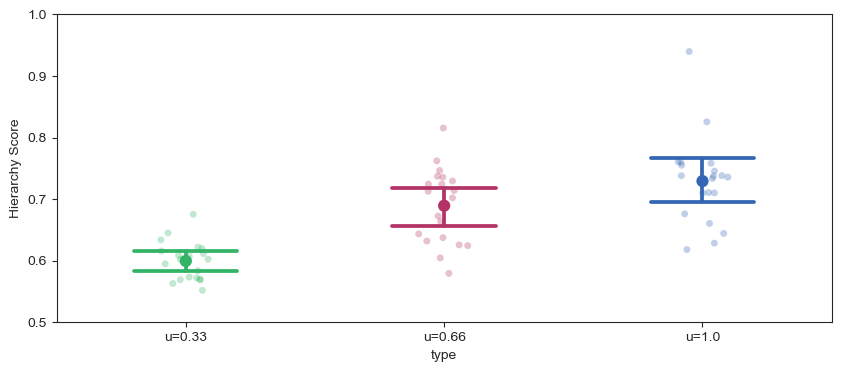

In [41]:
## first figure, only 

## Coal Figure 2. Plot every variable - swarm&box

typeofplot="swarmpoint"
#'swarmpoint' #'swarmbox' # choose among 'swarmbox', 'swarmpoint', violin

Variable2plot_list=['Additivity2_3', 'Additivity3_3', 'Assymetricity2_3', 'Assymetricity3_3']
    #['Additivity3_3', 'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
       #'Assymetricity1_3', 'Assymetricity2_3', 'Assymetricity3_3']

#What2plot='experiment' #What2plot='simulation' # or experiment
def HueAssign(i,j):
    return [j]
        
M = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
HueVariable='label'
hue_order = [0,1,2]
palette=[[0.2,0.7,0.4],[0.7,0.2,0.4],[0.2,0.4,0.7]]

df=pd.DataFrame()

data_list=[]
type_list=[]
data=hs1
data_list.extend(data)
type_list.extend(["u=0.33"] * len(data))
df_temp=pd.DataFrame({'data':data, 'type':type_list, HueVariable : HueAssign(i,j)*len(data)})
df=pd.concat([df,df_temp])

data_list=[]
type_list=[]
data=hs2
data_list.extend(data)
type_list.extend(["u=0.66"] * len(data))
df_temp=pd.DataFrame({'data':data, 'type':type_list, HueVariable : HueAssign(i,j)*len(data)})
df=pd.concat([df,df_temp])

data_list=[]
type_list=[]
data=hs3
data_list.extend(data)
type_list.extend(["u=1.0"] * len(data))
df_temp=pd.DataFrame({'data':data, 'type':type_list, HueVariable : HueAssign(i,j)*len(data)})
df=pd.concat([df,df_temp])
    
fig=figure(num=None, figsize=(10, 4), dpi=100, facecolor='w', edgecolor='k')

if typeofplot == 'swarmbox':
    sns.stripplot(x='type',y='data', data=df, palette=palette, size=5, alpha=0.3)
    sns.boxplot(x='type',y='data', data=df, dodge=False,  palette=palette,whis=0.5 ,width=0.3,fliersize=2)
elif typeofplot == 'swarmpoint':
    sns.stripplot(x='type',y='data', data=df, palette=palette, size=5, alpha=0.3)
    sns.pointplot(x='type',y='data',n_boot=200, data=df, errorbar=("ci",98), dodge=True,  palette=palette, capsize=0.4, join=False) 
elif typeofplot == 'prev1':
    sns.stripplot(x='type',y='data', data=df, color='black', size=5, alpha=0.1)
    sns.boxplot(x='type',y='data', data=df, dodge=True,  hue=HueVariable, hue_order=hue_order)
elif typeofplot == 'violin':
    sns.violinplot(x=x,y=y)
plt.ylabel("Hierarchy Score")
ax = plt.gca()
ax.set_ylim([0.5,1])
ax.get_legend().remove()
plt.title("Coal_Analysis")
plt.show()
#fig.savefig("Figures/0314_analysis/Coal_Analysis_"+What2plot+"_"+typeofplot+'_'+Variable2plot+".png", bbox_inches='tight')

    


#AllAbudnaces=getAbundance(Metadata['SampleIDX'])

/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/jysong/m

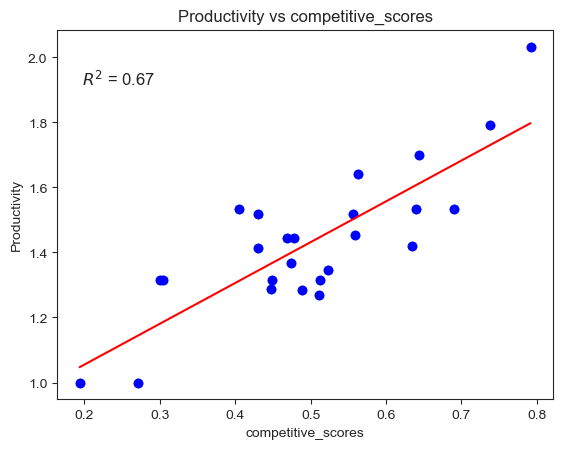

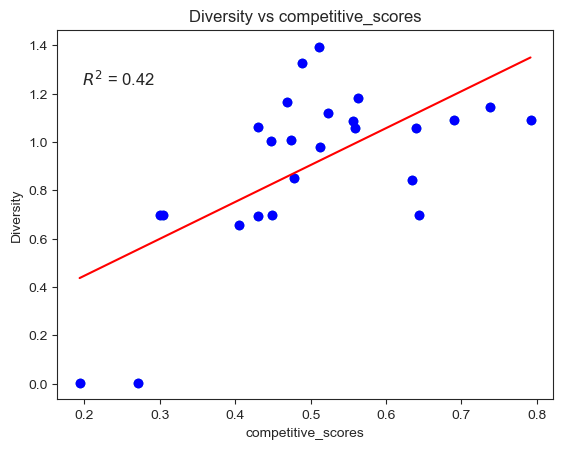

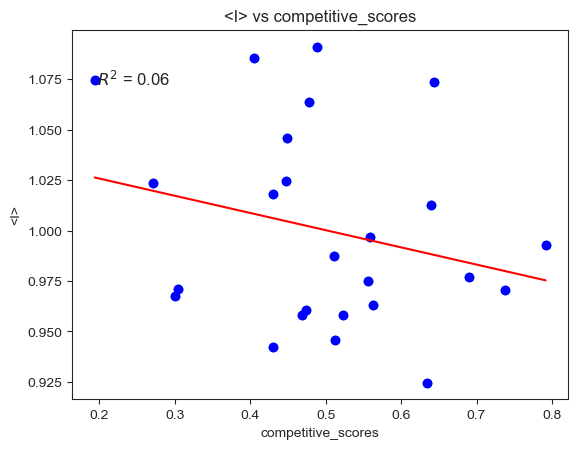

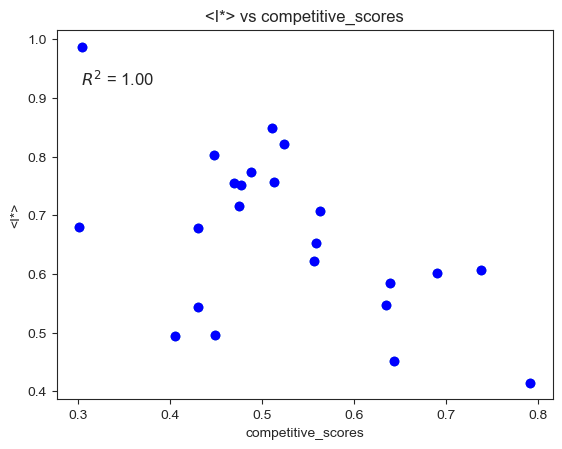

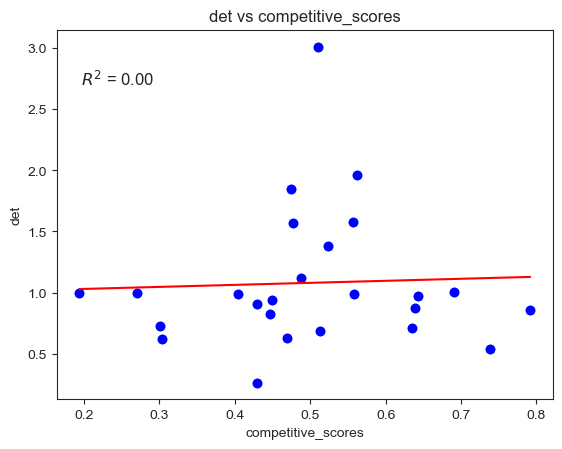

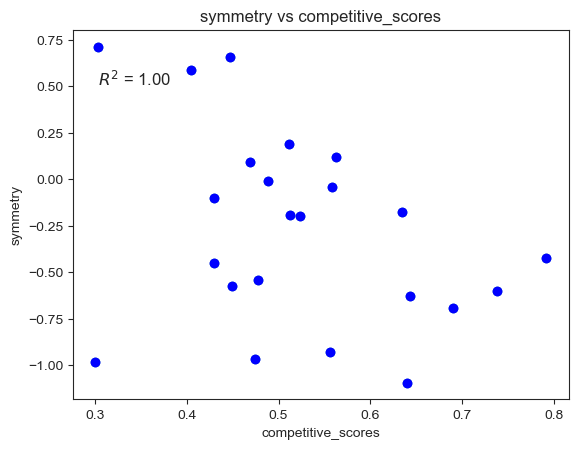

In [7]:
def internalI_mean_before_assembly(I, y_list, s_idx, threshold):
    
    s_idx=np.where(s_idx)[0].tolist()
    I_mean_1=I[s_idx,:]
    I_mean_1=I_mean_1[:,s_idx]
    I_mean_1=I_mean_1.flatten().tolist()
    #I_mean_1.remove(1.0)
    return mean(I_mean_1)

def internalI_mean_after_assembly(I, y_list, s_idx, threshold):
    s_idx=np.where(y_list>threshold)[0].tolist()
    I_mean_2=I[s_idx,:]
    I_mean_2=I_mean_2[:,s_idx]
    I_mean_2=I_mean_2.flatten().tolist()
    if 1.0 in I_mean_2:
        I_mean_2.remove(1.0)
    return mean(I_mean_2)

def internalI_symmetry(I, y_list, s_idx, threshold):
    s_idx=np.where(y_list>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    I_c=I_c.flatten().tolist()
    if 1.0 in I_c:
        I_c.remove(1.0)
    I_r=I_c[::-1]
    mean_I=mean(I_r)
    std_c = np.std(I_r)
    std_r = np.std(I_c)    
    cov = np.sum((I_r - mean_I) * (I_c - mean_I)) / (len(I_r) - 1)
    corr = cov / (std_c * std_r)
    return corr

def internalI_symmetry_weighted(I, y_list, s_idx, threshold):
    s_idx=np.where(y_list>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    I_c=np.multiply(I_c, y_list[s_idx])
    np.fill_diagonal(I_c,np.mean(I_c))
    I_c=I_c.flatten().tolist()
    I_r=I_c[::-1]
    mean_I=mean(I_r)
    std_c = np.std(I_r)
    std_r = np.std(I_c)    
    cov = np.sum((I_r - mean_I) * (I_c - mean_I)) / (len(I_r) - 1)
    corr = cov / (std_c * std_r)
    return corr

def internalI_det(I, y_list, s_idx, threshold):
    s_idx=np.where(y_list>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    return np.linalg.det(I_c)

def I_assay(I, y_list_all, sorted_idx, CommunitiesLibrary, competitive_scores, threshold):
    df=pd.DataFrame([])
    for i in sorted_idx:
        df_temp={}
        y_list=y_list_all[i,:]
        s_idx=CommunitiesLibrary[i,:]
        df_temp["Productivity"]=sum(y_list)
        df_temp["Diversity"]=Diversity2(y_list/sum(y_list),threshold)
        df_temp["<I>"]=internalI_mean_before_assembly(I, y_list, s_idx, threshold)
        df_temp["<I*>"]=internalI_mean_after_assembly(I, y_list, s_idx, threshold)
        df_temp["det"]=internalI_det(I, y_list, s_idx, threshold)
        df_temp["symmetry"]=internalI_symmetry(I,y_list,s_idx,threshold)
        df_temp["competitive_scores"]=competitive_scores[i]
        df_temp=pd.DataFrame(df_temp,index=[0])
        df=pd.concat([df,df_temp])
    return df

#for i in sorted_idx:
#    print (competitive_scores[i], i, sum(y_list[i,:]), Diversity2(y_list[i,:]/sum(y_list[i,:]), 0.0001) ,I_assay(I,y_list[i,:],CommunitiesLibrary[i,:],0.0001))

df=I_assay(I, y_list, sorted_idx, CommunitiesLibrary,competitive_scores, 0.0001)
# Example data
x_list = ["Productivity", "Diversity", '<I>','<I*>','det','symmetry']

# Iterate through x_list and plot x vs y for each variable
for x_var in x_list:
    x = df['competitive_scores']
    y = df[x_var]
    slope, intercept = np.polyfit(x, y, 1)
    plt.scatter(x, y)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # Create a scatter plot of the data
    plt.scatter(x, y, color='blue')

    # Add the linear regression line to the plot
    plt.plot(x, slope * x + intercept, color='red')

    # Add the R-squared value to the plot
    plt.annotate('$R^2$ = {:.2f}'.format(r_squared), xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)

    
    plt.xlabel('competitive_scores')
    plt.ylabel(x_var)
    plt.title(x_var + ' vs competitive_scores')
    plt.show()
    

    

In [8]:
I_copy=u*np.ones(np.shape(I))
for i in range(num_C):
    I_copy[i*num_S:i*num_S+num_S,i*num_S:i*num_S+num_S]=I[i*num_S:i*num_S+num_S,i*num_S:i*num_S+num_S]

In [9]:
for i in [0]:
    for j in [1]:
        y1= y_list[i,:]
        y2= y_list[j,:]

        
        y3=run_lotka_volterra((y1+y2)/2, np.linspace(0, 2500, 7500), (y1+y2)>threshold, I_copy, g, k)
        y3[y3<threshold]=0
        

In [10]:

DominanceMatrix_BC=np.zeros([num_C,num_C])
DominanceMatrix_J=np.zeros([num_C,num_C])
DominanceMatrix_JS=np.zeros([num_C,num_C])

threshold=0.0001
y_list=np.zeros([num_C,N])
for i in range(num_C):
    y=np.random.rand(N)*0.1
    y=run_lotka_volterra(y, np.linspace(0, 3500, 10000), CommunitiesLibrary[i,:], I_copy, g, k)
    y[y<threshold]=0
    y_list[i,:]=y

for i in range(num_C):
    for j in range(i,num_C):#range(i,num_C):
        y1= y_list[i,:]
        y2= y_list[j,:]

        
        y3=run_lotka_volterra((y1+y2)/2, np.linspace(0, 3500, 10000), (y1+y2)>threshold, I_copy, g, k)
        y3[y3<threshold]=0

        DominanceMatrix_BC[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))
        DominanceMatrix_BC[j,i]=1-DominanceMatrix_BC[i,j]
        DominanceMatrix_J[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityJ(x,y,z)))
        DominanceMatrix_J[j,i]=1-DominanceMatrix_J[i,j]
        DominanceMatrix_JS[i,j]=(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityJS(x,y,z)))
        DominanceMatrix_JS[j,i]=1-DominanceMatrix_JS[i,j]


        

/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/scipy/integrate/_odepack_py.py:248: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)
/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230212/SimulationResult/Simulation/VariousMetrics.py:31: RuntimeWarning: invalid value encountered in sqrt
  O = 1 - np.sqrt(0.5 * np.sum(A_ * (np.log(A_) - np.log(x))) + 0.5 * np.sum(B_ * (np.log(B_) - np.log(x))))


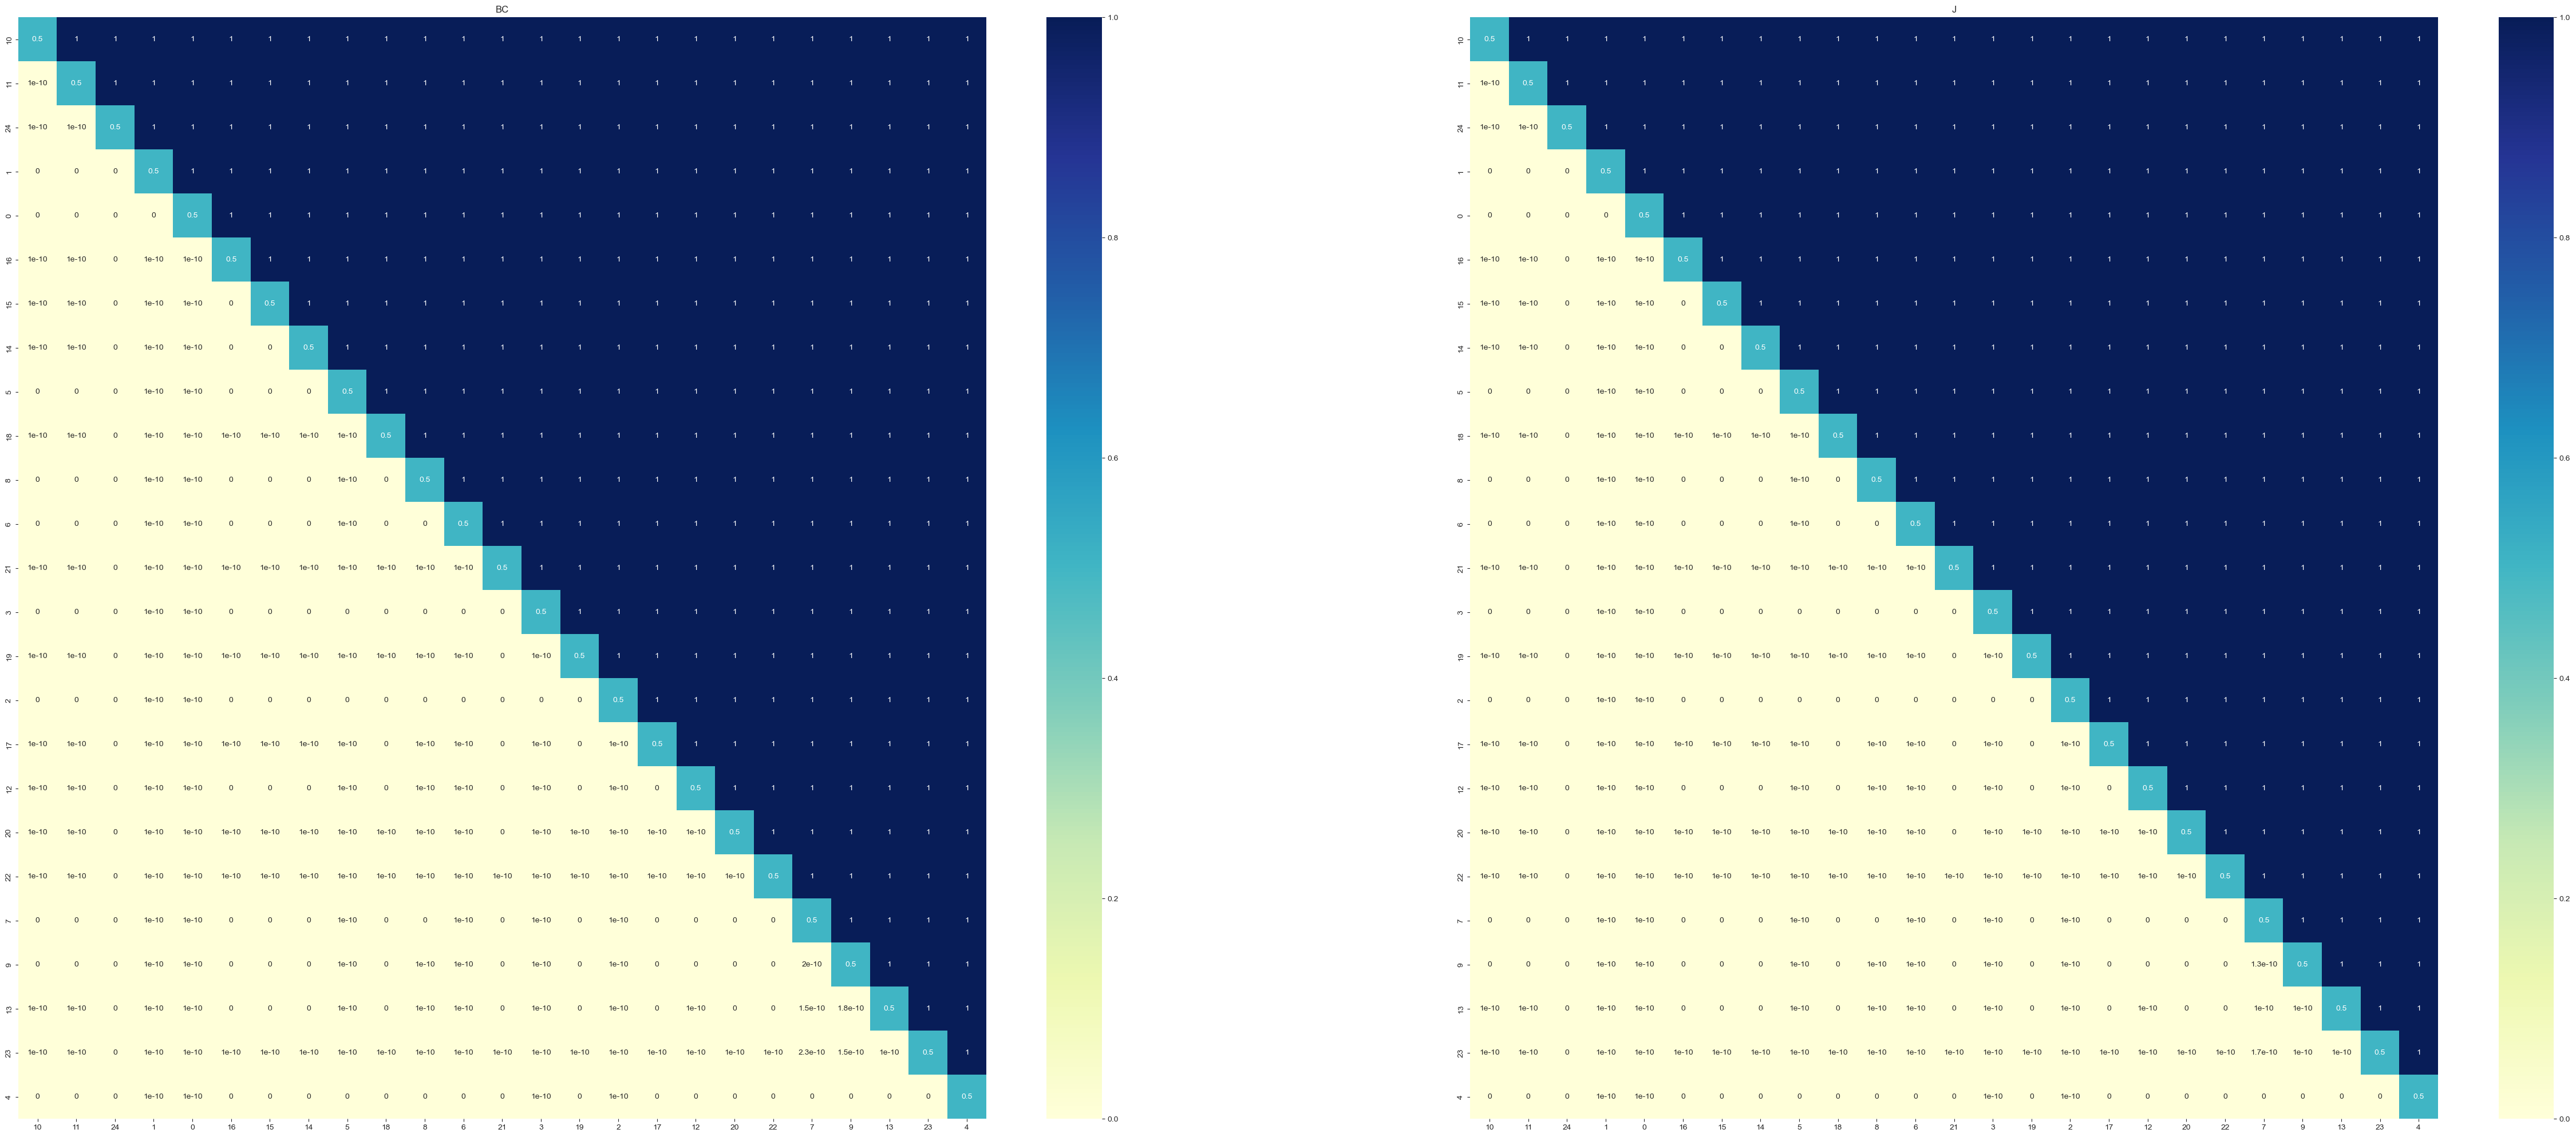

9.148368372943901

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(60, 25), dpi=100, facecolor='w', edgecolor='k')

rep=1
    
matrix=DominanceMatrix_BC
df = pd.DataFrame(matrix)
df_sorted=df.sort_index(axis=1)
df_sorted=df_sorted.sort_index(axis=0)

# Create list of competitive scores

competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

# Sort rows and columns by competitive score
sorted_idx = np.argsort(competitive_scores)[::-1]
df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
df1=df_sorted

# Create heatmap with clustered rows and columns
sns.heatmap(df1, annot=True, cmap='YlGnBu', vmin=0, vmax=1,ax=axs[0])
axs[0].set_title("BC")

matrix=DominanceMatrix_J
df = pd.DataFrame(matrix)
df_sorted=df.sort_index(axis=1)
df_sorted=df_sorted.sort_index(axis=0)

# Create list of competitive scores

competitive_scores = [np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

# Sort rows and columns by competitive score
sorted_idx = np.argsort(competitive_scores)[::-1]
df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
df1=df_sorted

# Create heatmap with clustered rows and columns
sns.heatmap(df1, annot=True, cmap='YlGnBu', vmin=0, vmax=1,ax=axs[1])
axs[1].set_title("J")

fig.savefig("Figures/Fig_session_1/Hiearchy_Analysis_largeNumber_intercommunityUniform"+str(u)+'_'+str(o)+'_'+str(num_C)+'_'+str(num_S)+".png", bbox_inches='tight')

plt.show()

hiearchy_score_1(DominanceMatrix_BC,competitive_scores, num_C)



/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/jysong/miniconda3/envs/jy_env/lib/python3.8/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


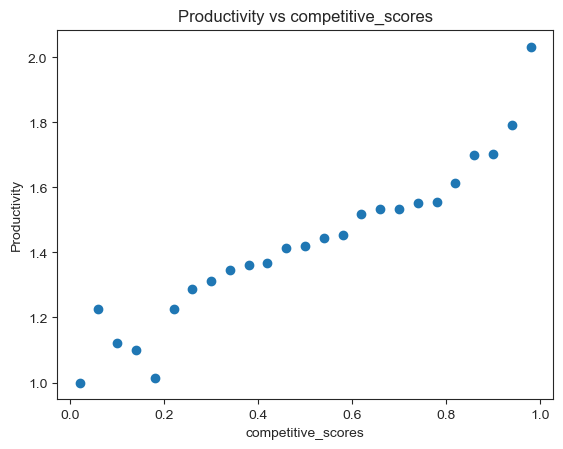

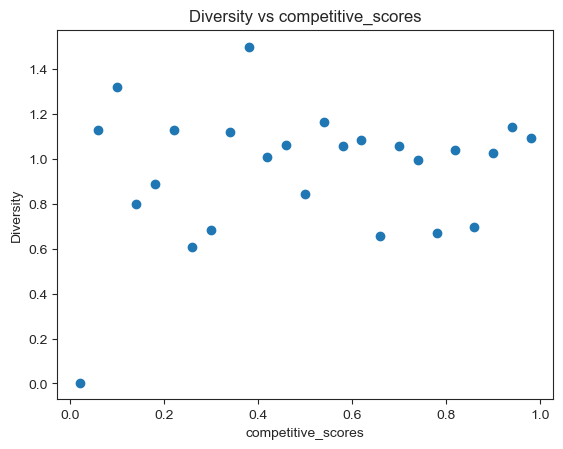

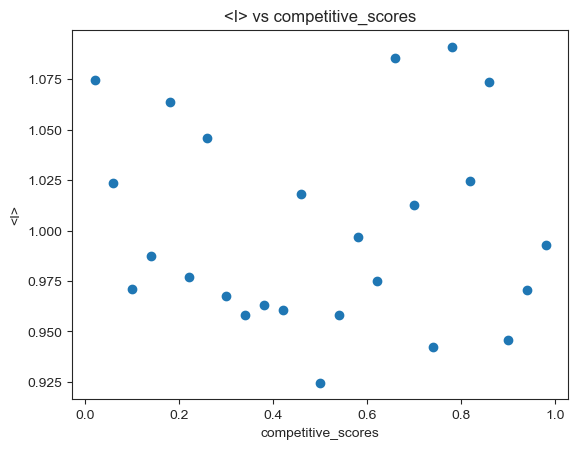

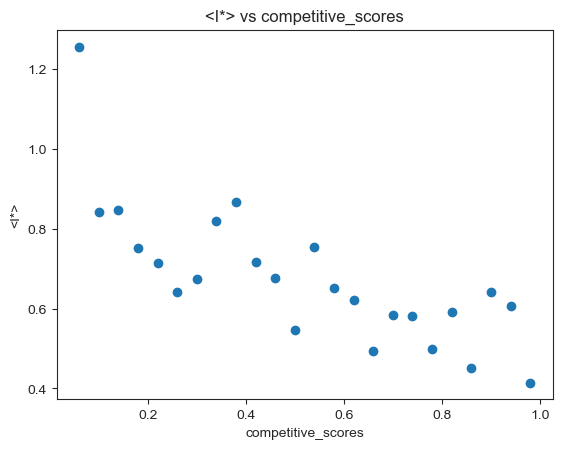

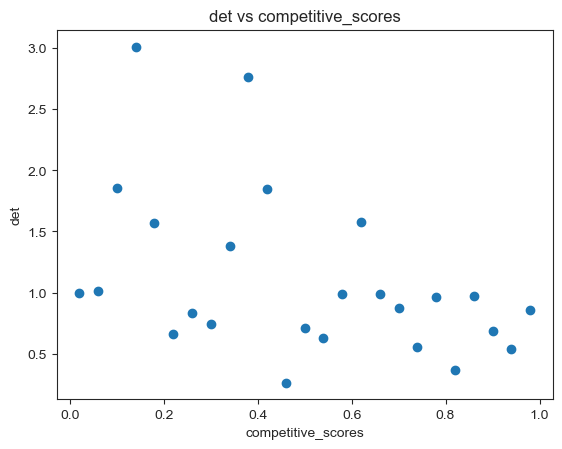

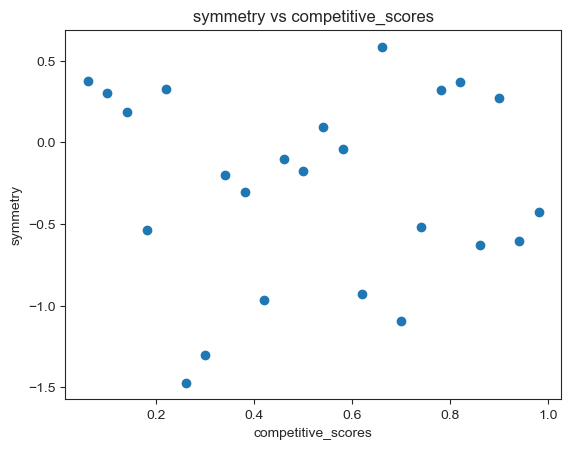

In [13]:
df=I_assay(I_copy, y_list, sorted_idx, CommunitiesLibrary,competitive_scores, 0.0001)
# Example data
x_list = ["Productivity", "Diversity", '<I>','<I*>','det','symmetry']

# Iterate through x_list and plot x vs y for each variable
for x_var in x_list:
    x = df['competitive_scores']
    y = df[x_var]
    plt.scatter(x, y)
    plt.xlabel('competitive_scores')
    plt.ylabel(x_var)
    plt.title(x_var + ' vs competitive_scores')
    plt.show()
    
    
    

In [ ]:

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(30, 30))

I_min=np.min(I[:])
I_max=np.max(I[:])

# Create a heat map for each N x N matrix in I, and plot it in the corresponding subplot
for i, ax in enumerate(axs.flatten()):
    s_idx=CommunitiesLibrary[sorted_idx[i],:]
    s_idx=np.where(s_idx)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    sns.heatmap(I_c, cmap='YlGnBu', vmin=I_min, vmax=I_max, ax=ax)
    ax.set_title('CS = {}'.format(str(competitive_scores[sorted_idx[i]]))[:10])

# Add a title to the figure
fig.suptitle('Heat maps of N x N matrices in a {} x N x N matrix'.format(I.shape[0]), fontsize=40)

# Display the figure
plt.show()
fig.savefig("Figures/Hiearchy_Analysis_largeNumber_heatmap_interaction_beforeAssembly"+str(u)+'_'+str(o)+'_'+str(num_C)+'_'+str(num_S)+".png", bbox_inches='tight')



In [ ]:

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(30, 30))

I_min=np.min(I[:])
I_max=np.max(I[:])

# Create a heat map for each N x N matrix in I, and plot it in the corresponding subplot
for i, ax in enumerate(axs.flatten()):
    s_idx=np.where(y_list[sorted_idx[i],:]>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    
    sns.heatmap(I_c, cmap='YlGnBu', vmin=I_min, vmax=I_max, ax=ax)
    ax.set_title('CS = {}'.format(str(competitive_scores[sorted_idx[i]]))[:10])

# Add a title to the figure
fig.suptitle('Heat maps of N x N matrices in a {} x N x N matrix'.format(I.shape[0]), fontsize=40)

# Display the figure
plt.show()
fig.savefig("Figures/Hiearchy_Analysis_largeNumber_heatmap_interaction_afterAssembly"+str(u)+'_'+str(o)+'_'+str(num_C)+'_'+str(num_S)+".png", bbox_inches='tight')



In [ ]:

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(30, 30))

I_min=np.min(I[:])
I_max=np.max(I[:])



# Sort rows and columns by competitive score



# Create a heat map for each N x N matrix in I, and plot it in the corresponding subplot
for i, ax in enumerate(axs.flatten()):
    s_idx=np.where(y_list[sorted_idx[i],:]>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    A=y_list[sorted_idx[i],:]
    A=A[np.where(A)]
    s_idx = np.argsort(A)
    I_c=I_c[s_idx,:]
    I_c=I_c[:,s_idx]
    
    sns.heatmap(I_c, cmap='YlGnBu', vmin=I_min, vmax=I_max, ax=ax)
    ax.set_title('CS = {}'.format(str(competitive_scores[sorted_idx[i]]))[:10])

# Add a title to the figure
fig.suptitle('Heat maps of N x N matrices in a {} x N x N matrix'.format(I.shape[0]), fontsize=40)

# Display the figure
plt.show()
fig.savefig("Figures/Hiearchy_Analysis_largeNumber_heatmap_interaction_beforeAssembly_sortbyY"+str(u)+'_'+str(o)+'_'+str(num_C)+'_'+str(num_S)+".png", bbox_inches='tight')



In [ ]:
    i=32    
    s_idx=np.where(y_list[sorted_idx[i],:]>threshold)[0].tolist()
    I_c=I[s_idx,:]
    I_c=I_c[:,s_idx]
    A=y_list[sorted_idx[i],:]
    A=A[np.where(A)]
    s_idx = np.argsort(A)
    I_c=I_c[s_idx,:]
    I_c=I_c[:,s_idx]
    I_c*A[s_idx]

In [ ]:
competitive_scores,sorted_idx

In [ ]:
y_list[sorted_idx[i],np.where(y_list[sorted_idx[i],:]>threshold)[0].tolist()]

In [ ]:
    A=y_list[sorted_idx[i],:]
    A=A[np.where(A)]
    A